# DSCI235 Final Project

https://github.com/Therasdin/DSCI235-Final.git

### Introduction

For this project, we analyzed a Spotify dataset containing various audio features of songs along with their popularity scores. The goal of this analysis is to explore how different musical characteristics, such as energy, danceability, tempo, and valence, relate to a song’s popularity. By examining these relationships, we aim to identify patterns that may help explain why certain songs are more popular than others.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
highPopularity = pd.read_csv("archive/high_popularity_spotify_data.csv")
lowPopularity = pd.read_csv("archive/low_popularity_spotify_data.csv")

highPopularity.head()


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [4]:
highPopularity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    1686 non-null   float64
 1   tempo                     1686 non-null   float64
 2   danceability              1686 non-null   float64
 3   playlist_genre            1686 non-null   object 
 4   loudness                  1686 non-null   float64
 5   liveness                  1686 non-null   float64
 6   valence                   1686 non-null   float64
 7   track_artist              1686 non-null   object 
 8   time_signature            1686 non-null   int64  
 9   speechiness               1686 non-null   float64
 10  track_popularity          1686 non-null   int64  
 11  track_href                1686 non-null   object 
 12  uri                       1686 non-null   object 
 13  track_album_name          1685 non-null   object 
 14  playlist

One of the first things we noticed was that the dataset contains a mix of continuous numerical features (such as energy, tempo, and loudness) and categorical or descriptive variables (such as artist name and playlist genre). The numerical features are mostly normalized or fall within expected ranges, making them suitable for comparison and analysis.

We also observed that some variables are encoded numerically but represent categorical information. For example, the “key” feature is represented as an integer from 0 to 11, corresponding to musical pitch classes (e.g., 0 = C, 1 = C♯, up to 11 = B), rather than being labeled directly. Similarly, the “mode” variable indicates whether a track is in a major or minor key. This means that some preprocessing or interpretation may be needed when analyzing these features.

In [6]:
print(highPopularity["track_popularity"].mean())
print(highPopularity["track_popularity"].std())

print(lowPopularity["track_popularity"].mean())
print(lowPopularity["track_popularity"].std())
features = [
    'energy', 'danceability', 'loudness', 'tempo',
    'valence', 'speechiness', 'instrumentalness',
    'liveness', 'acousticness', 'duration_ms'
]

comparison = pd.DataFrame({
    'High Mean': highPopularity[features].mean(),
    'Low Mean': lowPopularity[features].mean(),
    'High Std': highPopularity[features].std(),
    'Low Std': lowPopularity[features].std()
})

comparison['Difference'] = comparison['High Mean'] - comparison['Low Mean']

print(comparison.sort_values(by='Difference', ascending=False))

75.80604982206405
6.03253189985256
43.479173290938
14.821766430847045
                      High Mean       Low Mean      High Std       Low Std  \
duration_ms       214562.125741  201640.174300  58310.747929  91573.903523   
tempo                121.070938     116.766884     27.066029     29.152400   
loudness              -6.704131     -10.663833      3.377068      8.155066   
energy                 0.667216       0.543509      0.184908      0.263635   
valence                0.525737       0.458438      0.236113      0.266140   
danceability           0.650362       0.607268      0.157721      0.200372   
liveness               0.171579       0.165487      0.123953      0.124652   
speechiness            0.100926       0.102174      0.099748      0.101726   
acousticness           0.221220       0.405567      0.250593      0.342249   
instrumentalness       0.041520       0.286603      0.156556      0.395181   

                    Difference  
duration_ms       12921.951441  
tempo

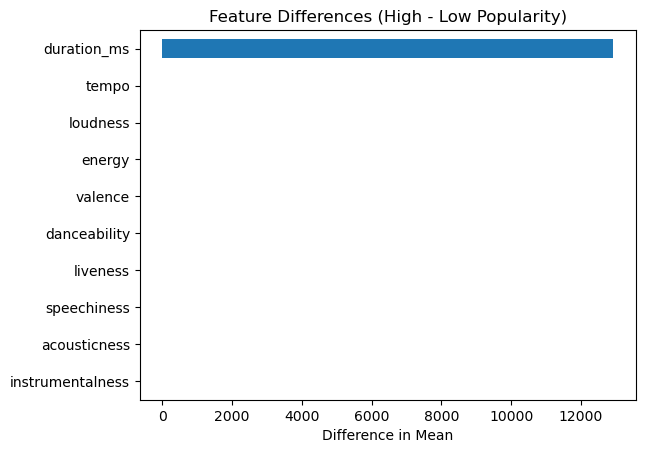

In [7]:
comparison['Difference'].sort_values().plot(kind='barh')
plt.title("Feature Differences (High - Low Popularity)")
plt.xlabel("Difference in Mean")
plt.show()

The data is split up into high and low popularity datasets. The High popularity dataset seems to have a lower distribution of songs. We first examined the distribution of popularity scores within the high and low popularity datasets by comparing their mean and standard deviation. The high popularity dataset had an average score of approximately 75.8 with a relatively small standard deviation of about 6.0, indicating that these songs are consistently rated within a narrow range of high popularity. In contrast, the low popularity dataset had a much lower average score of 43.5 and a significantly larger standard deviation of 14.8, showing that these songs vary widely in their popularity. This suggests that highly popular songs tend to follow a more consistent pattern, while less popular songs are more varied and less predictable in how they are received.


### Feature Comparison Analysis

We then compared the mean and standard deviation of key audio features between the high and low popularity datasets. Several clear differences emerged. High popularity songs tend to have higher loudness, energy, tempo, valence, and danceability, suggesting that they are generally louder, more energetic, more positive in mood, and more suitable for dancing. These traits point toward a more engaging and mainstream sound. Additionally, popular songs were slightly longer in duration on average.

On the other hand, low popularity songs showed much higher values for instrumentalness and acousticness, indicating that songs with fewer vocals or more acoustic qualities are less likely to achieve high popularity. Features such as liveness and speechiness showed little to no difference between the two groups, suggesting that they do not play a major role in determining popularity. Overall, this comparison highlights that popular songs tend to be more energetic and produced, while less popular songs tend to be more instrumental or acoustic.



In [11]:
corr_high = highPopularity.corr(numeric_only=True)['track_popularity'].sort_values(ascending=False)
corr_low = lowPopularity.corr(numeric_only=True)['track_popularity'].sort_values(ascending=False)

print("High Popularity Correlation:")
print(corr_high)

print("\nLow Popularity Correlation:")
print(corr_low)

High Popularity Correlation:
track_popularity    1.000000
loudness            0.083132
tempo               0.016659
mode                0.014359
liveness            0.004202
key                 0.001024
danceability       -0.002220
valence            -0.006478
energy             -0.007536
acousticness       -0.016960
instrumentalness   -0.063107
duration_ms        -0.066444
time_signature     -0.114827
speechiness        -0.137957
Name: track_popularity, dtype: float64

Low Popularity Correlation:
track_popularity    1.000000
danceability        0.083806
speechiness         0.078149
key                 0.025628
energy              0.017646
loudness            0.012829
liveness            0.007539
tempo               0.004540
valence             0.001621
instrumentalness   -0.003918
time_signature     -0.010980
mode               -0.034843
acousticness       -0.041779
duration_ms        -0.058848
Name: track_popularity, dtype: float64



To further understand relationships between features and popularity, we examined correlations within each dataset. In the high popularity dataset, correlations between individual features and popularity were generally very weak, with the strongest being loudness at only around 0.08. This suggests that once a song reaches a high level of popularity, its specific audio characteristics have little influence on further variation in popularity, and other external factors may be more important.

In contrast, the low popularity dataset showed slightly stronger correlations, particularly with danceability and speechiness. While still relatively small, these positive relationships suggest that songs with stronger rhythm and vocal presence may have a better chance of increasing in popularity within the lower popularity range. Overall, correlation analysis indicates that audio features have more influence when songs are less popular, but their impact diminishes at higher popularity levels.


In [12]:
genre_pop = highPopularity.groupby('playlist_genre')['track_popularity'].mean()
print(genre_pop.sort_values(ascending=False))

playlist_genre
gaming        80.430000
pop           80.042017
r&b           76.160000
soul          75.500000
k-pop         75.454545
latin         75.288043
folk          75.030303
rock          74.600000
ambient       74.278689
hip-hop       74.162996
arabic        73.980000
electronic    73.979730
metal         73.657143
punk          73.560000
indie         73.500000
brazilian     72.714286
blues         72.555556
afrobeats     72.050000
turkish       71.857143
world         71.750000
j-pop         71.636364
lofi          71.500000
reggae        70.600000
classical     70.600000
indian        70.555556
country       70.333333
korean        69.875000
jazz          69.000000
Name: track_popularity, dtype: float64


We also explored how popularity varies across different genres by comparing average popularity scores within the high popularity dataset. While some genres, such as gaming, pop, and R&B, showed slightly higher average popularity scores, the overall differences between genres were relatively small. This suggests that although genre may have some influence on popularity, it is not a dominant factor. Instead, the underlying audio features of a song appear to play a more significant role in determining its popularity than the genre classification alone.


In [13]:
key_counts = highPopularity['key'].value_counts().sort_index()
print(key_counts)

mode_counts = highPopularity['mode'].value_counts()
print(mode_counts)

key
0     152
1     227
2     154
3      53
4     123
5     153
6     134
7     151
8     119
9     136
10    112
11    172
Name: count, dtype: int64
mode
1    975
0    711
Name: count, dtype: int64


Finally, we analyzed the distribution of musical key and mode. The key variable, which is encoded as values from 0 to 11 representing musical pitch classes, was fairly evenly distributed across the dataset, indicating no strong preference for specific keys among popular songs. However, the mode variable showed a noticeable pattern, with a higher number of songs in major mode compared to minor mode in the high popularity dataset. This suggests that songs with a more positive or upbeat tonal structure, typically associated with major keys, may be more likely to achieve higher popularity.